In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kokiladang

In [4]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path

In [5]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    print("\nDirectory:", dirname)

    for file in filenames[:5]:
        print(file)


Directory: /kaggle/input

Directory: /kaggle/input/datasets

Directory: /kaggle/input/datasets/mukeshdevrath007

Directory: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data

Directory: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2
Kurtkoti.csv
Mohanpur.csv
Jaipur_2.csv
Hardia_2.csv
Jogbani.csv

Directory: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_3

Directory: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_3/w_d_3
Pudur_2.csv
Patan.csv
Paloncha.csv
Pariharpur_2.csv
Obra.csv

Directory: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis
weather-data-scraping-and-analysis.ipynb
weather.csv

Directory: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_1
Gulgam.csv
Buchireddipalem.csv
Budamangalam.csv
Dhekiajuli.csv
Dinapore.csv


In [6]:
dataset_path = "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data"

csv_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("Total CSV files:", len(csv_files))

csv_files[:10]

Total CSV files: 4686


['/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv',
 '/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv']

In [3]:
import pandas as pd

weather = pd.read_csv(
    "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv"
)

print(weather.shape)
weather.head()

(5933, 4)


,Unnamed: 0,city,lat,lng
0,0,Delhi,28.6100,77.2300
1,1,Mumbai,19.0761,72.8775
2,2,Kolkata,22.5675,88.3700
3,3,Bangalore,12.9789,77.5917
4,4,Chennai,13.0825,80.2750


In [14]:
df_list = []

for file in csv_files[:100]:   # Load only the first 100 files
    df = pd.read_csv(file)
    city = os.path.basename(file).replace(".csv", "")
    df["city"] = city
    df_list.append(df)

weather = pd.concat(df_list, ignore_index=True)

print(weather.shape)

(12393600, 22)


In [15]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12393600 entries, 0 to 12393599
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0            int64  
 1   date                  object 
 2   temperature_2m        float64
 3   relative_humidity_2m  float64
 4   dew_point_2m          float64
 5   apparent_temperature  float64
 6   precipitation         float64
 7   rain                  float64
 8   snowfall              float64
 9   snow_depth            float64
 10  pressure_msl          float64
 11  surface_pressure      float64
 12  cloud_cover           float64
 13  cloud_cover_low       float64
 14  cloud_cover_mid       float64
 15  cloud_cover_high      float64
 16  wind_speed_10m        float64
 17  wind_speed_100m       float64
 18  wind_direction_10m    float64
 19  wind_direction_100m   float64
 20  wind_gusts_10m        float64
 21  city                  object 
dtypes: float64(19), int64(1), object(2)
memo

In [17]:
weather.head()

,Unnamed: 0,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,...,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city
0,0,2010-01-01 00:00:00+00:00,19.417501,93.65456,18.367500,21.606852,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.120000,15.192682,90.000000,103.706985,10.799999,Kurtkoti
1,1,2010-01-01 01:00:00+00:00,19.117500,93.93506,18.117500,21.134613,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.519877,16.039202,83.659904,99.039406,12.240000,Kurtkoti
2,2,2010-01-01 02:00:00+00:00,19.217500,93.35163,18.117500,20.907986,0.0,0.0,0.0,0.0,...,3.6,0.0,6.0,0.0,8.759178,16.595179,80.537750,93.731330,15.119999,Kurtkoti
3,3,2010-01-01 03:00:00+00:00,21.217500,84.59197,18.517500,22.934296,0.0,0.0,0.0,0.0,...,3.6,0.0,6.0,0.0,9.826088,15.158522,81.573120,85.914470,21.960000,Kurtkoti
4,4,2010-01-01 04:00:00+00:00,23.417501,71.26092,17.917501,24.454496,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.599999,16.199999,90.000000,90.000000,29.880000,Kurtkoti


In [18]:
weather["date"] = pd.to_datetime(weather["date"])

print(weather["date"].dtype)

datetime64[ns, UTC]


In [19]:
print("Start Date :", weather["date"].min())
print("End Date   :", weather["date"].max())

Start Date : 2010-01-01 00:00:00+00:00
End Date   : 2024-02-20 23:00:00+00:00


In [20]:
print("Unique Cities :", weather["city"].nunique())

Unique Cities : 100


In [21]:
weather["city"].value_counts().head(20)

city
Kurtkoti              123936
Mohanpur              123936
Jaipur_2              123936
Hardia_2              123936
Jogbani               123936
Lakhipur_3            123936
Madakasira            123936
Khair Khan            123936
Kochi                 123936
Nanjanad              123936
Kokiladanga           123936
Mukhtarpur Salkani    123936
Nizampatam            123936
Kuniyamuttur          123936
Mandramo              123936
Lakhna                123936
Lakhnaur              123936
Mukerian              123936
Khalari               123936
Kathevaram            123936
Name: count, dtype: int64

In [22]:
missing = pd.DataFrame({
    "Missing Count": weather.isnull().sum(),
    "Missing Percent": weather.isnull().mean()*100
})

missing.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
Unnamed: 0,0,0.0
date,0,0.0
temperature_2m,0,0.0
relative_humidity_2m,0,0.0
dew_point_2m,0,0.0
apparent_temperature,0,0.0
precipitation,0,0.0
rain,0,0.0
snowfall,0,0.0
snow_depth,0,0.0


In [24]:
weather.duplicated().sum()

np.int64(0)

In [25]:
weather.duplicated(subset=["city","date"]).sum()

np.int64(0)

In [26]:
weather[
    (weather["relative_humidity_2m"] < 0) |
    (weather["relative_humidity_2m"] > 100)
]

,Unnamed: 0,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,...,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city


In [28]:
weather[
    (weather["cloud_cover"] < 0) |
    (weather["cloud_cover"] > 100)
]

,Unnamed: 0,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,...,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city


In [31]:
weather[
    weather["wind_speed_10m"] < 0
]

,Unnamed: 0,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,...,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city


In [36]:
corr = weather[numerical_cols].corr()

corr

,Unnamed: 0,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m
Unnamed: 0,1.000000,-0.024984,0.066036,0.043428,-0.007419,0.015345,0.015281,0.002422,-0.002331,0.061020,0.009290,-0.015739,-0.016204,-0.033135,0.024342,0.000125,0.004730,-0.005978,-0.014054,-0.014896
temperature_2m,-0.024984,1.000000,-0.480424,0.432720,0.950292,0.007824,0.009648,-0.063283,-0.191416,-0.621539,0.184826,0.070069,-0.053772,0.076765,0.149033,0.243961,0.098281,-0.059602,-0.031282,0.410853
relative_humidity_2m,0.066036,-0.480424,1.000000,0.550493,-0.213955,0.180492,0.180276,0.010727,-0.017864,-0.013977,0.077635,0.409917,0.355542,0.236583,0.289309,-0.126881,-0.012529,-0.093161,-0.090182,-0.265901
dew_point_2m,0.043428,0.432720,0.550493,1.000000,0.666235,0.168424,0.169970,-0.050754,-0.189516,-0.568449,0.262327,0.458339,0.278498,0.295577,0.424291,0.104446,0.077378,-0.161924,-0.133204,0.126071
apparent_temperature,-0.007419,0.950292,-0.213955,0.666235,1.000000,0.060669,0.062480,-0.061876,-0.190182,-0.682098,0.231299,0.193284,0.037570,0.145830,0.251815,0.137147,0.009096,-0.104528,-0.073316,0.306993
precipitation,0.015345,0.007824,0.180492,0.168424,0.060669,1.000000,0.999583,0.032373,0.004604,-0.151406,-0.004870,0.307433,0.252608,0.312626,0.220605,0.055571,0.053757,-0.024331,-0.020103,0.106339
rain,0.015281,0.009648,0.180276,0.169970,0.062480,0.999583,1.000000,0.003494,-0.002238,-0.152314,-0.002806,0.306791,0.251977,0.311584,0.220482,0.056032,0.054301,-0.024681,-0.020359,0.106574
snowfall,0.002422,-0.063283,0.010727,-0.050754,-0.061876,0.032373,0.003494,1.000000,0.237764,0.028834,-0.071833,0.027813,0.026393,0.041827,0.008225,-0.015034,-0.017967,0.011701,0.008549,-0.006247
snow_depth,-0.002331,-0.191416,-0.017864,-0.189516,-0.190182,0.004604,-0.002238,0.237764,1.000000,0.098796,-0.221792,0.018624,0.000358,0.046641,-0.000883,-0.042463,-0.060921,0.045042,0.022351,-0.018044
pressure_msl,0.061020,-0.621539,-0.013977,-0.568449,-0.682098,-0.151406,-0.152314,0.028834,0.098796,1.000000,-0.049753,-0.306122,-0.111376,-0.275458,-0.343376,-0.275227,-0.253681,0.033042,0.002651,-0.294672


In [37]:
corr = weather[numerical_cols].corr()

corr

,Unnamed: 0,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m
Unnamed: 0,1.000000,-0.024984,0.066036,0.043428,-0.007419,0.015345,0.015281,0.002422,-0.002331,0.061020,0.009290,-0.015739,-0.016204,-0.033135,0.024342,0.000125,0.004730,-0.005978,-0.014054,-0.014896
temperature_2m,-0.024984,1.000000,-0.480424,0.432720,0.950292,0.007824,0.009648,-0.063283,-0.191416,-0.621539,0.184826,0.070069,-0.053772,0.076765,0.149033,0.243961,0.098281,-0.059602,-0.031282,0.410853
relative_humidity_2m,0.066036,-0.480424,1.000000,0.550493,-0.213955,0.180492,0.180276,0.010727,-0.017864,-0.013977,0.077635,0.409917,0.355542,0.236583,0.289309,-0.126881,-0.012529,-0.093161,-0.090182,-0.265901
dew_point_2m,0.043428,0.432720,0.550493,1.000000,0.666235,0.168424,0.169970,-0.050754,-0.189516,-0.568449,0.262327,0.458339,0.278498,0.295577,0.424291,0.104446,0.077378,-0.161924,-0.133204,0.126071
apparent_temperature,-0.007419,0.950292,-0.213955,0.666235,1.000000,0.060669,0.062480,-0.061876,-0.190182,-0.682098,0.231299,0.193284,0.037570,0.145830,0.251815,0.137147,0.009096,-0.104528,-0.073316,0.306993
precipitation,0.015345,0.007824,0.180492,0.168424,0.060669,1.000000,0.999583,0.032373,0.004604,-0.151406,-0.004870,0.307433,0.252608,0.312626,0.220605,0.055571,0.053757,-0.024331,-0.020103,0.106339
rain,0.015281,0.009648,0.180276,0.169970,0.062480,0.999583,1.000000,0.003494,-0.002238,-0.152314,-0.002806,0.306791,0.251977,0.311584,0.220482,0.056032,0.054301,-0.024681,-0.020359,0.106574
snowfall,0.002422,-0.063283,0.010727,-0.050754,-0.061876,0.032373,0.003494,1.000000,0.237764,0.028834,-0.071833,0.027813,0.026393,0.041827,0.008225,-0.015034,-0.017967,0.011701,0.008549,-0.006247
snow_depth,-0.002331,-0.191416,-0.017864,-0.189516,-0.190182,0.004604,-0.002238,0.237764,1.000000,0.098796,-0.221792,0.018624,0.000358,0.046641,-0.000883,-0.042463,-0.060921,0.045042,0.022351,-0.018044
pressure_msl,0.061020,-0.621539,-0.013977,-0.568449,-0.682098,-0.151406,-0.152314,0.028834,0.098796,1.000000,-0.049753,-0.306122,-0.111376,-0.275458,-0.343376,-0.275227,-0.253681,0.033042,0.002651,-0.294672


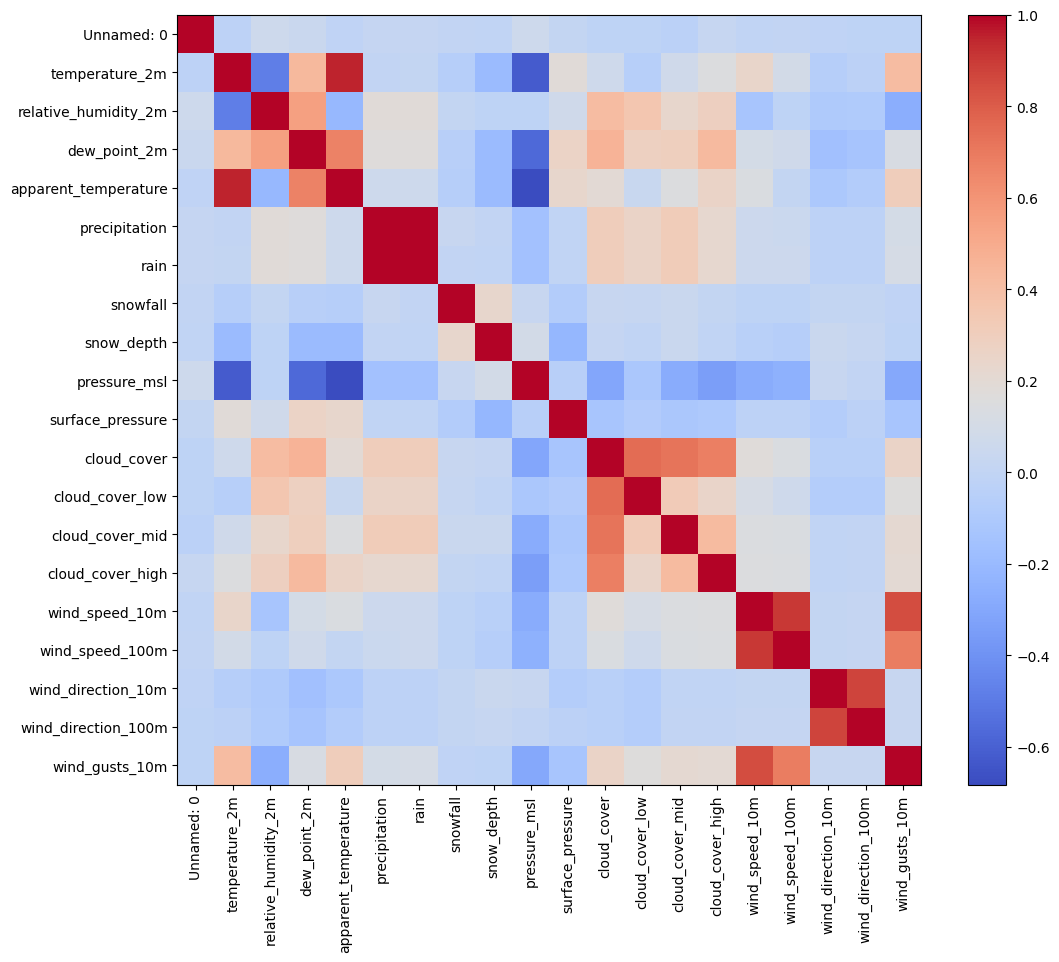

In [38]:
plt.figure(figsize=(12,10))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.show()

In [39]:
corr_matrix = weather[numerical_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    (column, idx, upper.loc[idx, column])
    for column in upper.columns
    for idx in upper.index
    if pd.notna(upper.loc[idx, column]) and upper.loc[idx, column] > 0.90
]

for feature1, feature2, corr_value in high_corr:
    print(feature1, feature2, corr_value)

apparent_temperature temperature_2m 0.9502924347035003
rain precipitation 0.9995827189279997
wind_speed_100m wind_speed_10m 0.9041074011728784


In [41]:
weather["date"] = pd.to_datetime(weather["date"])

weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month
weather["day"] = weather["date"].dt.day
weather["hour"] = weather["date"].dt.hour
weather["weekday"] = weather["date"].dt.day_name()

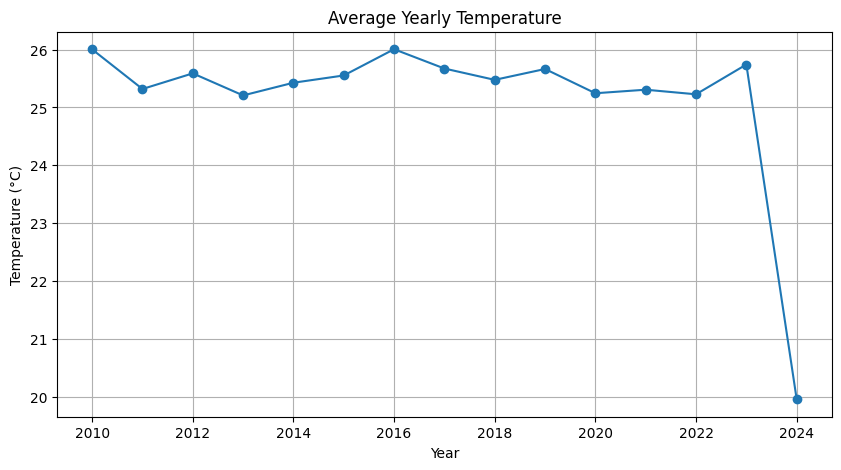

In [42]:
import matplotlib.pyplot as plt

yearly_temp = weather.groupby("year")["temperature_2m"].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly_temp.index, yearly_temp.values, marker="o")
plt.title("Average Yearly Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [43]:
monthly = weather.groupby("month")[
    ["temperature_2m", "rain", "relative_humidity_2m"]
].mean()

monthly

,temperature_2m,rain,relative_humidity_2m
month,,,
1,19.162116,0.020772,70.448269
2,21.882829,0.020724,62.388063
3,25.956914,0.028198,55.029473
4,29.109570,0.055126,54.372694
5,30.149270,0.122060,60.314512
6,29.371033,0.250873,69.780693
7,27.660691,0.375886,79.084598
8,27.309109,0.342421,80.647421
9,26.947095,0.296229,80.970710


In [48]:
hourly = weather.groupby("hour")[
    ["temperature_2m", "relative_humidity_2m"]
].mean()

hourly

,temperature_2m,relative_humidity_2m
hour,,
0,21.465958,85.239804
1,21.686796,84.746090
2,22.894444,80.372922
3,24.818804,72.369680
4,26.617902,65.027552
5,28.104710,59.177481
6,29.210230,54.936618
7,29.874670,52.542343
8,30.231108,51.117661


In [49]:
def season(month):

    if month in [6,7,8,9]:
        return "Monsoon"

    elif month in [10,11]:
        return "Post-Monsoon"

    elif month in [12,1,2]:
        return "Winter"

    else:
        return "Summer"

weather["season"] = weather["month"].apply(season)

In [6]:
import os
import re
import pandas as pd

paths = {
    "weather":"/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis",
    "w_d_1": "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_1",
    "w_d_2": "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2",
    "w_d_3": "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_3/w_d_3"
}

for folder, folder_path in paths.items():

    print(f"\nProcessing {folder}")

    cities = []

    for file in os.listdir(folder_path):

        if file.endswith(".csv"):

            original = os.path.splitext(file)[0]
            base = re.sub(r'_\d+$', '', original)

            cities.append([original, base])

    df = pd.DataFrame(cities, columns=["Original_Name", "Base_City"])

    print(df.head())
    print("Rows:", len(df))

    duplicates = (
        df.groupby("Base_City")
          .filter(lambda x: len(x) > 1)
          .sort_values(["Base_City", "Original_Name"])
    )

    print("Duplicate Base Cities:", duplicates["Base_City"].nunique())
    print("Duplicate Files:", len(duplicates))

    display(duplicates)

    duplicates.to_csv(f"/kaggle/working/{folder}_duplicates.csv", index=False)


Processing weather
  Original_Name Base_City
0       weather   weather
Rows: 1
Duplicate Base Cities: 0
Duplicate Files: 0


,Original_Name,Base_City



Processing w_d_1
     Original_Name        Base_City
0           Gulgam           Gulgam
1  Buchireddipalem  Buchireddipalem
2     Budamangalam     Budamangalam
3       Dhekiajuli       Dhekiajuli
4         Dinapore         Dinapore
Rows: 1762
Duplicate Base Cities: 66
Duplicate Files: 167


,Original_Name,Base_City
581,Akbarpur,Akbarpur
800,Akbarpur_2,Akbarpur
162,Alampur,Alampur
344,Alampur_2,Alampur
364,Alampur_3,Alampur
722,Amaravati,Amaravati
822,Amaravati_2,Amaravati
401,Ambala,Ambala
1355,Ambala_2,Ambala
765,Ammapettai,Ammapettai



Processing w_d_2
  Original_Name Base_City
0      Kurtkoti  Kurtkoti
1      Mohanpur  Mohanpur
2      Jaipur_2    Jaipur
3      Hardia_2    Hardia
4       Jogbani   Jogbani
Rows: 2087
Duplicate Base Cities: 92
Duplicate Files: 207


,Original_Name,Base_City
1675,Hajipur,Hajipur
1505,Hajipur_2,Hajipur
1562,Hajipur_3,Hajipur
1117,Hardia,Hardia
3,Hardia_2,Hardia
1200,Hardiya,Hardiya
697,Hardiya_2,Hardiya
1405,Haripur,Haripur
747,Haripur_2,Haripur
1603,Harohalli,Harohalli



Processing w_d_3
  Original_Name   Base_City
0       Pudur_2       Pudur
1         Patan       Patan
2      Paloncha    Paloncha
3  Pariharpur_2  Pariharpur
4          Obra        Obra
Rows: 836
Duplicate Base Cities: 40
Duplicate Files: 100


,Original_Name,Base_City
4,Obra,Obra
225,Obra_2,Obra
447,Paharpur,Paharpur
71,Paharpur_2,Paharpur
223,Pakala,Pakala
616,Pakala_2,Pakala
549,Pali,Pali
583,Pali_2,Pali
372,Pali_3,Pali
222,Pallappalaiyam,Pallappalaiyam


In [23]:
import os

print(os.listdir("/kaggle/input/datasets/teb34swapnilkamble/gro-json/india_district.geojson"))


['india_district.geojson']


In [25]:
import geopandas as gpd

geo = gpd.read_file(
   "/kaggle/input/datasets/teb34swapnilkamble/gro-json/india_district.geojson"
)

geo.head()

,ID_0,ISO,NAME_0,ID_1,NAME_1,ID_2,NAME_2,NL_NAME_2,VARNAME_2,TYPE_2,ENGTYPE_2,geometry
0,105,IND,India,1,Andaman and Nicobar,1,Andaman Islands,None,None,District,District,"MULTIPOLYGON (((92.51583 10.89764, 92.51611 10..."
1,105,IND,India,1,Andaman and Nicobar,2,Nicobar Islands,None,None,District,District,"MULTIPOLYGON (((93.78773 6.85264, 93.78849 6.8..."
2,105,IND,India,2,Andhra Pradesh,3,Adilabad,None,None,District,District,"POLYGON ((78.33625 19.88319, 78.34669 19.8814,..."
3,105,IND,India,2,Andhra Pradesh,4,Anantapur,None,"Anantpur, Ananthapur",District,District,"POLYGON ((77.69 15.17628, 77.69378 15.17347, 7..."
4,105,IND,India,2,Andhra Pradesh,5,Chittoor,None,Chitoor|Chittor,District,District,"POLYGON ((78.47611 13.9368, 78.48208 13.93007,..."


In [30]:
import pandas as pd
import geopandas as gpd

# -----------------------------
# Read Weather CSV
# -----------------------------
weather = pd.read_csv(
    "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/Weather_Data_Scraping_and_Analysis/weather.csv"
)

# -----------------------------
# Read GeoJSON
# -----------------------------
geo = gpd.read_file(
    "/kaggle/input/datasets/teb34swapnilkamble/gro-json/india_district.geojson"
)

# -----------------------------
# Create GeoDataFrame from weather
# -----------------------------
weather_gdf = gpd.GeoDataFrame(
    weather,
    geometry=gpd.points_from_xy(weather["lng"], weather["lat"]),
    crs="EPSG:4326"
)

# -----------------------------
# Spatial Join
# -----------------------------
merged = gpd.sjoin(
    weather_gdf,
    geo[["NAME_0", "NAME_1", "NAME_2", "geometry"]],
    how="left",
    predicate="within"
)

# -----------------------------
# Rename Columns
# -----------------------------
merged = merged.rename(columns={
    "NAME_0": "country",
    "NAME_1": "state",
    "NAME_2": "district"
})

# -----------------------------
# Remove unwanted columns
# -----------------------------
merged = merged.drop(columns=["geometry", "index_right"])

# -----------------------------
# Save
# -----------------------------
merged.to_csv(
    "/kaggle/working/weather_with_geo.csv",
    index=False
)

print(merged.head())

   Unnamed: 0       city      lat      lng country        state  \
0           0      Delhi  28.6100  77.2300   India        Delhi   
1           1     Mumbai  19.0761  72.8775   India  Maharashtra   
2           2    Kolkata  22.5675  88.3700   India  West Bengal   
3           3  Bangalore  12.9789  77.5917   India    Karnataka   
4           4    Chennai  13.0825  80.2750   India   Tamil Nadu   

          district  
0            Delhi  
1   Greater Bombay  
2          Kolkata  
3  Bangalore Urban  
4          Chennai  


In [31]:
import os
import pandas as pd

# --------------------------
# Geo Lookup File
# --------------------------
geo = pd.read_csv("/kaggle/working/weather_with_geo.csv")

# Remove duplicate cities
geo = geo.drop_duplicates(subset=["city"])

# Base dataset path
base_path = "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data"

folders = {
    "w_d_1": os.path.join(base_path, "w_d_1"),
    "w_d_2": os.path.join(base_path, "w_d_2"),
    "w_d_3": os.path.join(base_path, "w_d_3")
}

# Output folder
output_root = "/kaggle/working/weather_geo"
os.makedirs(output_root, exist_ok=True)

for folder_name, folder_path in folders.items():

    output_folder = os.path.join(output_root, folder_name)
    os.makedirs(output_folder, exist_ok=True)

    print(f"\nProcessing {folder_name}")

    for file in os.listdir(folder_path):

        if not file.endswith(".csv"):
            continue

        city = os.path.splitext(file)[0]

        # Remove _1,_2,_3...
        base_city = city.rsplit("_", 1)[0] if city.rsplit("_",1)[-1].isdigit() else city

        weather = pd.read_csv(os.path.join(folder_path, file))

        weather["city"] = base_city

        merged = weather.merge(
            geo,
            on="city",
            how="left"
        )

        merged.to_csv(
            os.path.join(output_folder, file),
            index=False
        )

    print("Completed:", folder_name)

print("Finished Successfully")


Processing w_d_1


OSError: [Errno 28] No space left on device

In [2]:
import shutil

total, used, free = shutil.disk_usage("/kaggle/working")

print(f"Total: {total/1024**3:.2f} GB")
print(f"Used : {used/1024**3:.2f} GB")
print(f"Free : {free/1024**3:.2f} GB")

NameError: name 'to' is not defined

In [14]:
import shutil

shutil.rmtree("/kaggle/working/weather_geo", ignore_errors=True)

In [11]:
import shutil

shutil.rmtree("/kaggle/working/weather_geo", ignore_errors=True)

In [35]:
import os
import random

base_path = "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_1"

csv_files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

# Randomly select 100 files
sample_files = random.sample(csv_files, 100)

print("Total Sample Files:", len(sample_files))
print(sample_files[:10])

Total Sample Files: 100
['Gopalapuram.csv', 'Barahkurwa.csv', 'Chembagaramanpudur.csv', 'Bajwara.csv', 'Andiyappanur.csv', 'Ghatal.csv', 'Ahmadnagar.csv', 'Fateh Nangal.csv', 'Barahpur.csv', 'Asansol.csv']


In [37]:
import os
import random

base_path = "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_1"

csv_files = [f for f in os.listdir(base_path) if f.endswith(".csv")]

# Randomly select 100 files
sample_files = random.sample(csv_files, 100)

print("Total Sample Files:", len(sample_files))
print(sample_files[:10])

Total Sample Files: 100
['Gadarwara.csv', 'Datiana.csv', 'Balangir.csv', 'Deodora.csv', 'Chicalim.csv', 'Beladi.csv', 'Agadallanka.csv', 'Fyzabad.csv', 'Belampalli.csv', 'Chinnampalaiyam.csv']


In [58]:
import os
import random
import re
import pandas as pd

# -----------------------------
# Geo lookup table
# -----------------------------
geo = pd.read_csv("/kaggle/working/weather_with_geo.csv")

geo = geo[["city", "country", "state", "district", "lat", "lng"]]
geo = geo.drop_duplicates(subset=["city"])

# -----------------------------
# Dataset folders
# -----------------------------
base_path = "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data"

folders = {
    "w_d_1": os.path.join(base_path, "w_d_1"),
    "w_d_2": os.path.join(base_path, "w_d_2"),
    "w_d_3": os.path.join(base_path, "w_d_3", "w_d_3")  # nested
}

sample_size = 100

all_data = []

for folder, folder_path in folders.items():

    files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

    sample_files = random.sample(files, min(sample_size, len(files)))

    print(f"Processing {folder}: {len(sample_files)} cities")

    for file in sample_files:

        city = os.path.splitext(file)[0]

        # Remove suffix (_1, _2, ...)
        city = re.sub(r'_\d+$', '', city)

        df = pd.read_csv(os.path.join(folder_path, file))

        df["city"] = city

        # Merge geo information
        df = df.merge(
            geo,
            on="city",
            how="left"
        )

        df["source_folder"] = folder

        all_data.append(df)

# ------------------------------------
# Combine all 300 cities into one DataFrame
# ------------------------------------
final_df = pd.concat(all_data, ignore_index=True)

print("Total Rows :", len(final_df))
print("Total Cities :", final_df["city"].nunique())

# Save one CSV
output_file = "/kaggle/working/weather_300_cities.csv"
final_df.to_csv(output_file, index=False)

print("Saved to:", output_file)

display(final_df.head())

Processing w_d_1: 100 cities
Processing w_d_2: 100 cities
Processing w_d_3: 100 cities
Total Rows : 37180800
Total Cities : 298
Saved to: /kaggle/working/weather_300_cities.csv


,Unnamed: 0,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,...,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city,country,state,district,lat,lng,source_folder
0,0,2010-01-01 00:00:00+00:00,20.234999,97.252710,19.785000,23.468706,0.0,0.0,0.0,0.0,...,323.130000,19.983198,8.280000,Gummudipundi,India,Tamil Nadu,Thiruvallur,13.3995,80.1187,w_d_1
1,1,2010-01-01 01:00:00+00:00,20.234999,97.554650,19.835000,23.478050,0.0,0.0,0.0,0.0,...,330.945500,21.801476,8.640000,Gummudipundi,India,Tamil Nadu,Thiruvallur,13.3995,80.1187,w_d_1
2,2,2010-01-01 02:00:00+00:00,21.585000,96.388245,20.984999,25.343779,0.0,0.0,0.0,0.0,...,340.016800,16.699326,12.959999,Gummudipundi,India,Tamil Nadu,Thiruvallur,13.3995,80.1187,w_d_1
3,3,2010-01-01 03:00:00+00:00,24.785000,83.428240,21.785000,28.823463,0.0,0.0,0.0,0.0,...,15.945477,23.198618,16.919998,Gummudipundi,India,Tamil Nadu,Thiruvallur,13.3995,80.1187,w_d_1
4,4,2010-01-01 04:00:00+00:00,25.984999,74.652680,21.135000,28.946404,0.0,0.0,0.0,0.0,...,47.862484,49.398785,25.560000,Gummudipundi,India,Tamil Nadu,Thiruvallur,13.3995,80.1187,w_d_1


In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/working/weather_300_cities.csv")

print(df.head())

KeyboardInterrupt: 

In [ ]:
city_weather = (
    df.groupby("city")
      .agg({
          "temperature_2m": "mean",
          "relative_humidity_2m": "mean",
          "precipitation": "mean",
          "rain": "mean",
          "pressure_msl": "mean",
          "cloud_cover": "mean",
          "wind_speed_10m": "mean",
          "lat": "first",
          "lng": "first"
      })
      .reset_index()
)

print(city_weather.head())

In [ ]:
city_weather = (
    df.groupby("city")
      .agg({
          "temperature_2m": "mean",
          "relative_humidity_2m": "mean",
          "precipitation": "mean",
          "rain": "mean",
          "pressure_msl": "mean",
          "cloud_cover": "mean",
          "wind_speed_10m": "mean",
          "lat": "first",
          "lng": "first"
      })
      .reset_index()
)

print(city_weather.head())

In [51]:
from sklearn.preprocessing import StandardScaler

features = [
    "lat",
    "lng",
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "pressure_msl",
    "cloud_cover"
]

X = city_weather[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

city_weather["Cluster"] = kmeans.fit_predict(X_scaled)

print(city_weather.head())

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

city_weather["Cluster"] = kmeans.fit_predict(X_scaled)

print(city_weather.head())

In [15]:
import os
import random
import re
import pandas as pd

geo = pd.read_csv("/kaggle/working/weather_with_geo.csv")
geo = geo.drop_duplicates("city")

base_path = "/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data"

folders = {
    "w_d_1": os.path.join(base_path, "w_d_1"),
    "w_d_2": os.path.join(base_path, "w_d_2"),
    "w_d_3": os.path.join(base_path, "w_d_3", "w_d_3")
}

sample_size = 100

city_summary = []

for folder, path in folders.items():

    files = [f for f in os.listdir(path) if f.endswith(".csv")]
    sample = random.sample(files, min(sample_size, len(files)))

    for file in sample:

        city = re.sub(r'_\d+$', '', os.path.splitext(file)[0])

        df = pd.read_csv(os.path.join(path, file))

        info = geo[geo["city"] == city]

        if info.empty:
            continue

        city_summary.append({
            "city": city,
            "temperature_2m": df["temperature_2m"].mean(),
            "relative_humidity_2m": df["relative_humidity_2m"].mean(),
            "precipitation": df["precipitation"].mean(),
            "rain": df["rain"].mean(),
            "pressure_msl": df["pressure_msl"].mean(),
            "cloud_cover": df["cloud_cover"].mean(),
            "wind_speed_10m": df["wind_speed_10m"].mean(),
            "lat": info.iloc[0]["lat"],
            "lng": info.iloc[0]["lng"],
            "state": info.iloc[0]["state"]
        })

city_weather = pd.DataFrame(city_summary)

print(city_weather.head())
print("Total Cities:", city_weather["city"].nunique())

        city  temperature_2m  relative_humidity_2m  precipitation      rain  \
0  Ghorbanki       24.520625             71.511924       0.182857  0.182857   
1    Balvadi       26.445218             58.144194       0.117488  0.117488   
2  Dhenkanal       26.681609             74.316577       0.186744  0.186744   
3     Guduru       27.828789             57.019200       0.079309  0.079309   
4     Bhakua       24.404735             71.884061       0.183519  0.183519   

   pressure_msl  cloud_cover  wind_speed_10m      lat      lng           state  
0   1007.888861    28.420448        9.640627  26.5697  86.0484           Bihar  
1   1009.021314    27.934834        9.642914  21.4412  75.2230  Madhya Pradesh  
2   1007.837913    33.765166        7.242103  20.6700  85.6000          Orissa  
3   1009.128056    33.185144       11.335988  15.7748  77.8074  Andhra Pradesh  
4   1007.829056    28.244703        9.337414  26.5167  86.1974           Bihar  
Total Cities: 293


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "pressure_msl",
    "cloud_cover",
    "wind_speed_10m",
    "lat",
    "lng"
]

X = city_weather[features]

X = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

city_weather["Cluster"] = kmeans.fit_predict(X)

city_weather.head()

,city,temperature_2m,relative_humidity_2m,precipitation,rain,pressure_msl,cloud_cover,wind_speed_10m,lat,lng,state,Cluster
0,Ghorbanki,24.520625,71.511924,0.182857,0.182857,1007.888861,28.420448,9.640627,26.5697,86.0484,Bihar,3
1,Balvadi,26.445218,58.144194,0.117488,0.117488,1009.021314,27.934834,9.642914,21.4412,75.2230,Madhya Pradesh,1
2,Dhenkanal,26.681609,74.316577,0.186744,0.186744,1007.837913,33.765166,7.242103,20.6700,85.6000,Orissa,3
3,Guduru,27.828789,57.019200,0.079309,0.079309,1009.128056,33.185144,11.335988,15.7748,77.8074,Andhra Pradesh,4
4,Bhakua,24.404735,71.884061,0.183519,0.183519,1007.829056,28.244703,9.337414,26.5167,86.1974,Bihar,3


In [21]:
from sklearn.preprocessing import StandardScaler

features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "pressure_msl",
    "cloud_cover",
    "wind_speed_10m",
    "lat",
    "lng"
]

X = city_weather[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

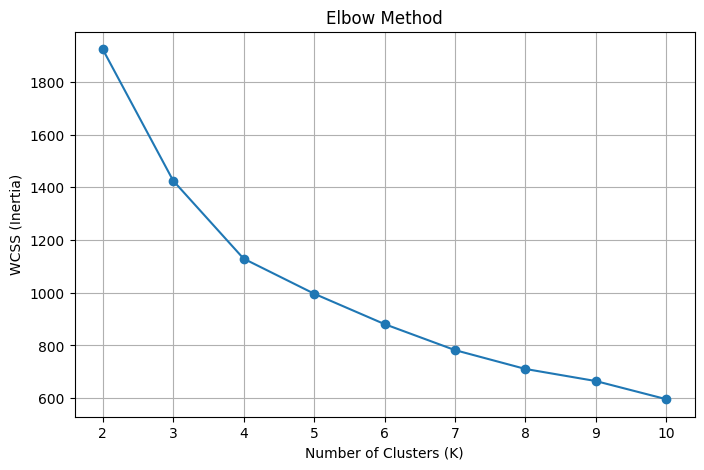

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [25]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

city_weather["Cluster"] = kmeans.fit_predict(X_scaled)

In [26]:
city_weather.sort_values(["Cluster", "city"]).head(30)

,city,temperature_2m,relative_humidity_2m,precipitation,rain,pressure_msl,cloud_cover,wind_speed_10m,lat,lng,state,Cluster
41,Adigappadi,26.249977,65.985292,0.102547,0.102547,1010.225576,41.600938,9.697304,12.1459,78.0946,Tamil Nadu,0
96,Anjehalli,26.269002,65.043624,0.105878,0.105878,1010.200694,41.136803,9.815484,12.1395,77.9808,Tamil Nadu,0
63,Arasur,25.931281,70.642337,0.122266,0.122266,1010.235889,48.330866,11.551347,11.0866,77.1146,Tamil Nadu,0
6,Atharga,27.284717,55.223650,0.082643,0.082643,1009.510655,32.188307,14.710132,16.9875,75.8863,Karnataka,0
58,Bagalur,23.232989,69.130728,0.104194,0.104194,1011.361465,45.088991,11.917865,13.1328,77.6685,Karnataka,0
83,Bangalore,23.015389,69.424099,0.115151,0.115151,1011.368965,46.254928,11.704065,12.9789,77.5917,Karnataka,0
66,Belur,22.163637,74.793893,0.159410,0.159410,1011.994109,53.553527,9.878131,13.1642,75.8647,Karnataka,0
18,Chintamani,23.481811,67.162781,0.091217,0.091217,1011.091724,42.392019,12.236551,13.4000,78.0660,Karnataka,0
65,Chittarkottal,28.081008,74.009084,0.128415,0.128415,1008.953282,37.785949,14.969426,9.4276,78.9015,Tamil Nadu,0
28,Cuddalore,27.861627,74.989308,0.134966,0.134966,1008.812197,37.958007,12.854546,11.7500,79.7500,Tamil Nadu,0


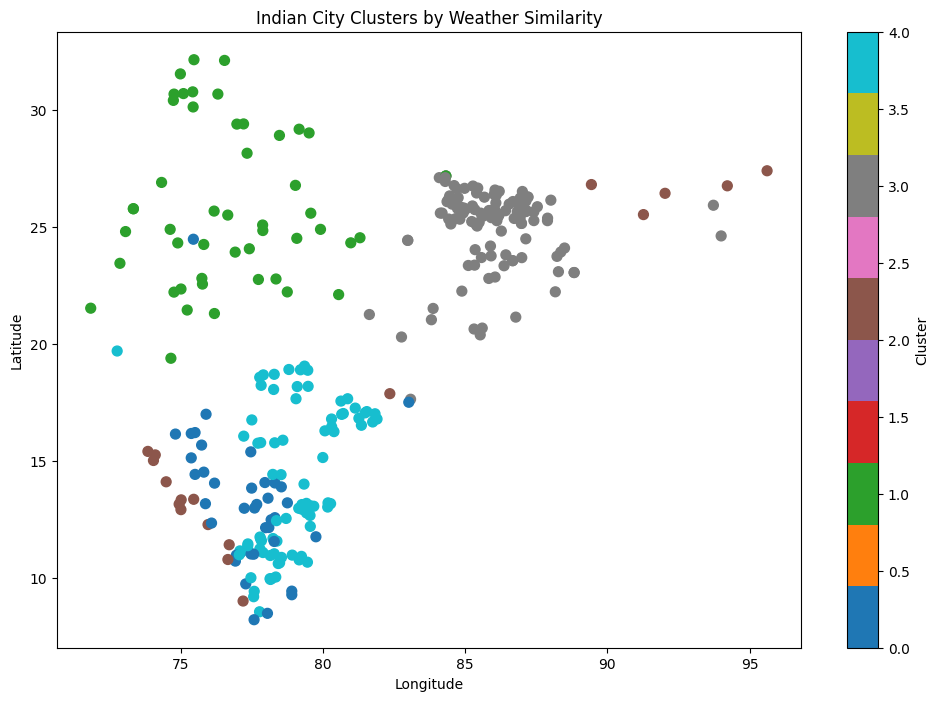

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.scatter(
    city_weather["lng"],
    city_weather["lat"],
    c=city_weather["Cluster"],
    cmap="tab10",
    s=50
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Indian City Clusters by Weather Similarity")

plt.colorbar(label="Cluster")
plt.show()